## >> Prediction with LinearRegression

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# READ THE HEIGHT AND WEIGHT DATASET FROM CSV FILE
main = pd.read_csv("C:/Users/Admin/Documents/arc_model_core/ml_docs/Datasets/height_weight.csv")
main.head(10)

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160
5,78,162
6,80,163
7,90,175
8,95,182
9,78,170


In [2]:
# DISPLAY DATASET INFORMATION (DATA TYPES, NON-NULL COUNTS, MEMORY USAGE)
main.info()
display(main.isnull().sum())

<class 'pandas.DataFrame'>
RangeIndex: 23 entries, 0 to 22
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Weight  23 non-null     int64
 1   Height  23 non-null     int64
dtypes: int64(2)
memory usage: 500.0 bytes


Weight    0
Height    0
dtype: int64

In [3]:
# DISPLAY SUMMARY STATISTICS OF THE DATASET
main.describe()

,Weight,Height
count,23.000000,23.000000
mean,73.826087,158.391304
std,17.872407,19.511626
min,45.000000,120.000000
25%,59.000000,142.500000
50%,78.000000,162.000000
75%,86.000000,175.000000
max,105.000000,183.000000


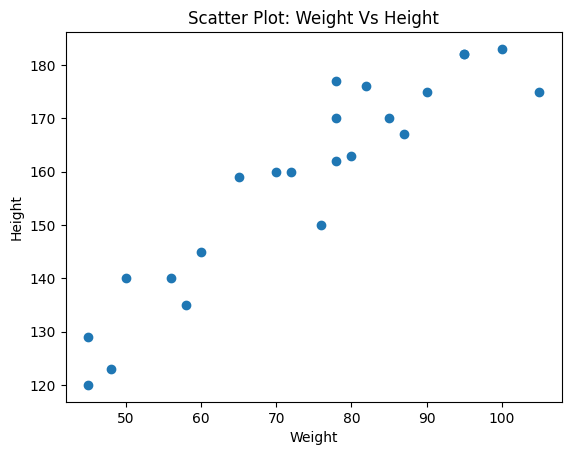

In [4]:
# CREATE A SCATTER PLOT TO VISUALIZE THE RELATIONSHIP BETWEEN WEIGHT AND HEIGHT
plt.scatter(main['Weight'], main['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')
plt.title('Scatter Plot: Weight Vs Height')
plt.show()

In [5]:
# SEPARATE FEATURES (X) AND TARGET VARIABLE (y)
X = main[["Weight"]]            # FEATURE: WEIGHT (INDEPENDENT VARIABLE)
y = main["Height"]              # TARGET: HEIGHT (DEPENDENT VARIABLE)

# SPLIT THE DATA INTO TRAINING AND TESTING SETS (80% TRAIN, 20% TEST)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=50)

# DISPLAY THE SHAPES OF ALL DATASETS
print(f":> FEATURES SHAPE (X): {X.shape}")
print(f":> FEATURES SHAPE (y): {y.shape}")

print(f"\n:> TRAINING FEATURES SHAPE (X_train): {X_train.shape}")
print(f":> TESTING FEATURES SHAPE (X_test): {X_test.shape}")
print(f":> TRAINING TARGET SHAPE (y_train): {y_train.shape}")
print(f":> TESTING TARGET SHAPE (y_test): {y_test.shape}")

:> FEATURES SHAPE (X): (23, 1)
:> FEATURES SHAPE (y): (23,)

:> TRAINING FEATURES SHAPE (X_train): (18, 1)
:> TESTING FEATURES SHAPE (X_test): (5, 1)
:> TRAINING TARGET SHAPE (y_train): (18,)
:> TESTING TARGET SHAPE (y_test): (5,)


In [6]:
# INITIALIZE STANDARD SCALER FOR FEATURE NORMALIZATION
scaler = StandardScaler()

# APPLY STANDARD SCALING (Z-SCORE NORMALIZATION) TO TRAINING AND TEST DATA
X_train = scaler.fit_transform(X_train)             # FIT AND TRANSFORM ON TRAINING DATA
X_test = scaler.transform(X_test)                   # ONLY TRANSFORM ON TESTING DATA (USING TRAINING STATISTICS)

# DISPLAY THE SCALED TEST FEATURES
X_test

array([[ 0.10122204],
       [-1.11344245],
       [ 1.86248556],
       [-1.78150793],
       [ 0.22268849]])

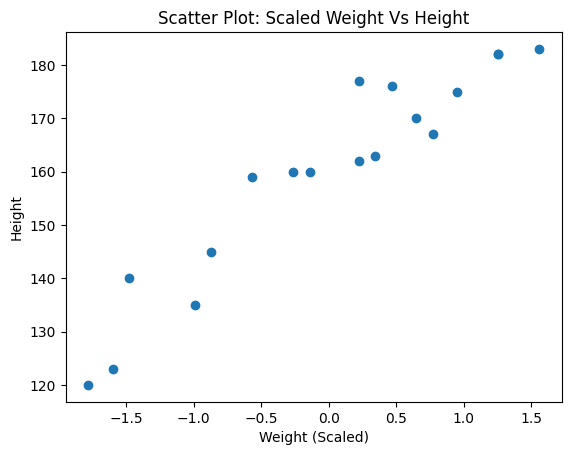

In [7]:
# CREATE A SCATTER PLOT OF SCALED TRAINING DATA
plt.scatter(X_train, y_train)
plt.xlabel("Weight (Scaled)")
plt.ylabel("Height")
plt.title("Scatter Plot: Scaled Weight Vs Height")
plt.show()

In [8]:
# TRANSFORM A NEW VALUE (80 kg) USING THE FITTED SCALER FOR PREDICTION
scaler.transform([[80]])

c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.34415494]])

In [9]:
# INITIALIZE AND TRAIN THE LINEAR REGRESSION MODEL
linear = LinearRegression()
linear.fit(X_train, y_train)

# DISPLAY THE MODEL PARAMETERS
print(f":> MODEL INTERCEPT (B0): {linear.intercept_}")
print(f":> MODEL COEFFICIENT (B1): {linear.coef_}")

:> MODEL INTERCEPT (B0): 159.94444444444446
:> MODEL COEFFICIENT (B1): [18.24133653]


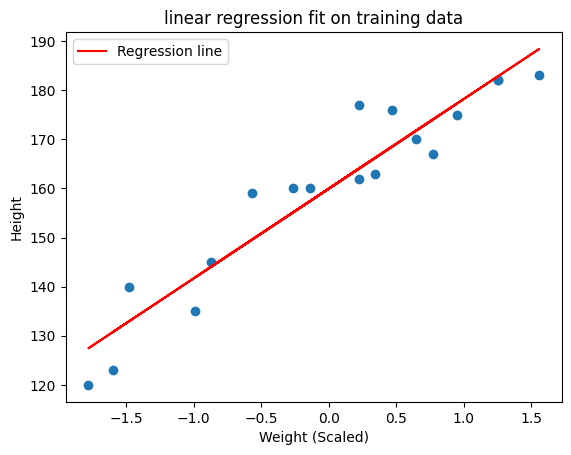

In [10]:
# VISUALIZE THE REGRESSION LINE ON TRAINING DATA
plt.scatter(X_train, y_train)
plt.plot(X_train, linear.predict(X_train), 'r', label='Regression line')
plt.xlabel("Weight (Scaled)")
plt.ylabel("Height")
plt.title("linear regression fit on training data")
plt.legend()
plt.show()

In [ ]:
# MAKE PREDICTIONS ON THE TEST SET
y_test_predict = linear.predict(X_test)

# DISPLAY ACTUAL Vs PREDICTED VALUES
print(":> PREDICTED HEIGHTS >>")
display(y_test_predict)

print("\n:> ACTUAL HEIGHTS >>")
display(y_test)

:> PREDICTED HEIGHTS >>


array([161.79086976, 139.63376594, 193.91867031, 127.44735883,
       164.00658015])


:> ACTUAL HEIGHTS >>


18    150
21    140
12    175
20    129
9     170
Name: Height, dtype: int64

In [14]:
# CALCULATE REGRESSION METRICS
MSE = mean_squared_error(y_test, y_test_predict)            # MEAN SQUARED ERROR
MAE = mean_absolute_error(y_test, y_test_predict)           # MEAN ABSOLUTE ERROR
RMSE = np.sqrt(MSE)                                         # ROOT MEAN SQUARED ERROR
score = r2_score(y_test, y_test_predict)                    # R-SQUARED SCORE


# CALCULATE ADJUSTED R-SQUARED
n = len(y_test)             # NUMBER OF TEST SAMPLES
k = X_test.shape[1]         # NUMBER OF FEATURES
adjusted_r2 = 1 - (1 - score) * (n - 1) / (n - k -1)


# DISPLAY THE EVALUATION METRICS
print("=" * 50)
print("=>> MODEL EVALUATION METRICS >>")
print("=" * 50)
print(f">> MEAN SQUARED ERROR (MSE): {MSE:.4f}")
print(f">> MEAN ABSOLUTE ERROR (MAE): {MAE:.4f}")
print(f">> ROOT MEAN SQUARED ERROR (RMSE): {RMSE:.4f}")
print(f">> R-SQUARED SCORE (R²): {score:.4f}")
print(f">> ADJUSTED R-SQUARED SCORE: {adjusted_r2:.4f}")
print("=" * 50)

=>> MODEL EVALUATION METRICS >>
>> MEAN SQUARED ERROR (MSE): 107.0813
>> MEAN ABSOLUTE ERROR (MAE): 7.7244
>> ROOT MEAN SQUARED ERROR (RMSE): 10.3480
>> R-SQUARED SCORE (R²): 0.6493
>> ADJUSTED R-SQUARED SCORE: 0.5324


In [21]:
# OPTIONAL: PREDICT HEIGHT FOR A NEW WEIGHT (e.g., 75 wgt)
new_weight = np.array([[75]])
new_weight_scaled = scaler.transform(new_weight)
predicted_height = linear.predict(new_weight_scaled)
print(f":> PREDICTED HEIGHT(cm) FOR 75 WEIGHT: {predicted_height[0]:,.2f}")

:> PREDICTED HEIGHT(cm) FOR 75 WEIGHT: 160.68


c:\Users\Admin\AppData\Local\Programs\Python\Python314\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
